# 🤖 StartupCoach — Model Training Pipeline

This notebook trains and evaluates machine learning models for startup success prediction using Crunchbase data.

Input:
- `cleaned_crunchbase.csv`
- Generated from `1_data_preprocessing.ipynb`

Goal:
Predict whether a startup will be acquired (`1`) or closed (`0`) based on funding and company-related features.

Pipeline:
1. Load the cleaned dataset
2. Encode categorical features
3. Split train and test sets
4. Train baseline and ensemble models
5. Evaluate model performance
6. Analyze feature importance
7. Export the final trained model

## Step 1: Imports & Configuration

In [1]:
# =========================
# Core Libraries
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Machine Learning
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# =========================
# Model Saving
# =========================
import joblib

# =========================
# Notebook Style
# =========================
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## Step 2: Load Cleaned Dataset

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
import os
FOLDER_NAME = 'startupcoach'
GOOGLE_DRIVE_PATH = os.path.join('/content/drive/MyDrive', FOLDER_NAME)
print(os.listdir(GOOGLE_DRIVE_PATH))

['crunchbase_raw.csv', 'cleaned_crunchbase.csv']


In [4]:
# Load Data
DATA_FILE = 'cleaned_crunchbase.csv'
df = pd.read_csv(os.path.join(GOOGLE_DRIVE_PATH, DATA_FILE), low_memory=False, encoding='latin-1')
print(f"Dataset loaded successfully: {df.shape}")

Dataset loaded successfully: (6295, 17)


## Step 3: Encode Remaining Categorical Features

In [5]:
categorical_cols = ['market', 'country_code']

# Clean categorical values
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown').astype(str).str.strip()

In [6]:
# Group rare categories
TOP_N = 20

for col in categorical_cols:
    top_categories = df[col].value_counts().head(TOP_N).index
    df[col] = df[col].apply(lambda x: x if x in top_categories else 'Other')

    print(f"{col}: {df[col].nunique()} categories after grouping")

market: 21 categories after grouping
country_code: 21 categories after grouping


In [7]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

Original shape: (6295, 17)
Encoded shape: (6295, 55)


Categorical features were grouped and one-hot encoded for machine learning compatibility.

In [8]:
df = df_encoded.copy()
print(df.shape)

(6295, 55)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6295 entries, 0 to 6294
Data columns (total 55 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   funding_total_usd           6295 non-null   float64
 1   funding_rounds              6295 non-null   float64
 2   founded_year                6295 non-null   float64
 3   seed                        6295 non-null   float64
 4   venture                     6295 non-null   float64
 5   debt_financing              6295 non-null   float64
 6   angel                       6295 non-null   float64
 7   grant                       6295 non-null   float64
 8   round_A                     6295 non-null   float64
 9   round_B                     6295 non-null   float64
 10  round_C                     6295 non-null   float64
 11  round_D                     6295 non-null   float64
 12  round_E                     6295 non-null   float64
 13  round_F                     6295 

## Step 4: Train-Test Split
The dataset is split into training and testing sets to evaluate model performance on unseen data.

An 80/20 split is used, where 80% of the data is used for training and 20% for evaluation.

In [10]:
# Define features and target
X = df.drop(columns=['success'])
y = df['success']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5036, 54)
Testing set shape: (1259, 54)


## Step 5: Baseline Model — Logistic Regression
Logistic Regression is used as a baseline classification model for startup success prediction.

Although relatively simple, it provides a strong reference point for evaluating more advanced ensemble models later in the pipeline.

In [11]:
# Train Logistic Regression model
log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully")

✅ Logistic Regression model trained successfully


In [12]:
# Generate predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [13]:
def evaluate_model(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': auc
    }

In [14]:
# Evaluate Logistic Regression
log_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log,
    y_prob_log
)


Logistic Regression Performance:
Accuracy : 0.6942
Precision: 0.6925
Recall   : 0.8604
F1 Score : 0.7674
ROC AUC  : 0.7371


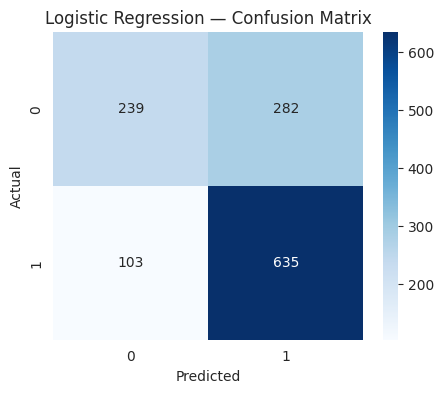

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The Logistic Regression baseline achieved moderate predictive performance, with relatively high recall for successful startups.

The results suggest that startup success patterns can be partially learned from funding and company-related features, although classification errors remain significant.

## Step 6: Decision Tree Model

Decision Trees can capture non-linear decision boundaries and feature interactions that linear models may fail to learn.

This model is evaluated against the Logistic Regression baseline.

In [16]:
# Train Decision Tree model
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully")

✅ Decision Tree model trained successfully


In [17]:
# Generate predictions
y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

In [18]:
# Evaluate Decision Tree
tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_tree,
    y_prob_tree
)


Decision Tree Performance:
Accuracy : 0.7069
Precision: 0.7457
Recall   : 0.7588
F1 Score : 0.7522
ROC AUC  : 0.7412


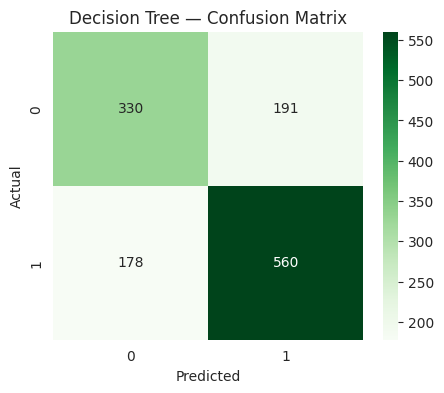

In [19]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The Decision Tree model captures more complex feature relationships compared to Logistic Regression.

Its performance will later be compared with ensemble-based methods such as Random Forest.

## Step 7: Random Forest Model
Random Forest is an ensemble learning method that combines multiple decision trees to improve generalization and reduce overfitting.

It is expected to outperform the previous baseline models on structured startup funding data.

In [20]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully")

✅ Random Forest model trained successfully


In [21]:
# Generate predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [22]:
# Evaluate Random Forest
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


Random Forest Performance:
Accuracy : 0.7180
Precision: 0.7409
Recall   : 0.7981
F1 Score : 0.7684
ROC AUC  : 0.7795


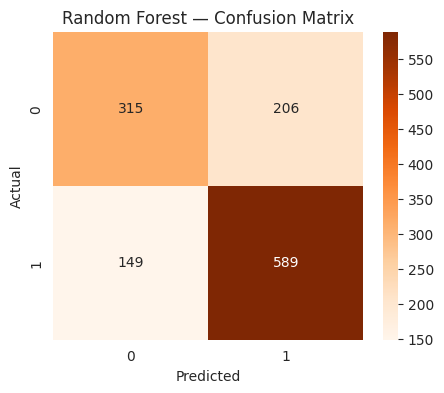

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The Random Forest model combines multiple decision trees to improve predictive stability and reduce overfitting.

Its performance provide the strongest overall results among the evaluated models.

## Step 8: Model Evaluation & Comparison
The evaluated models are compared using multiple classification metrics to determine the most effective approach for startup success prediction.

In [24]:
results_df = pd.DataFrame([
    log_results,
    tree_results,
    rf_results
])

results_df = results_df.round(4)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.6942,0.6925,0.8604,0.7674,0.7371
1,Decision Tree,0.7069,0.7457,0.7588,0.7522,0.7412
2,Random Forest,0.7180,0.7409,0.7981,0.7684,0.7795


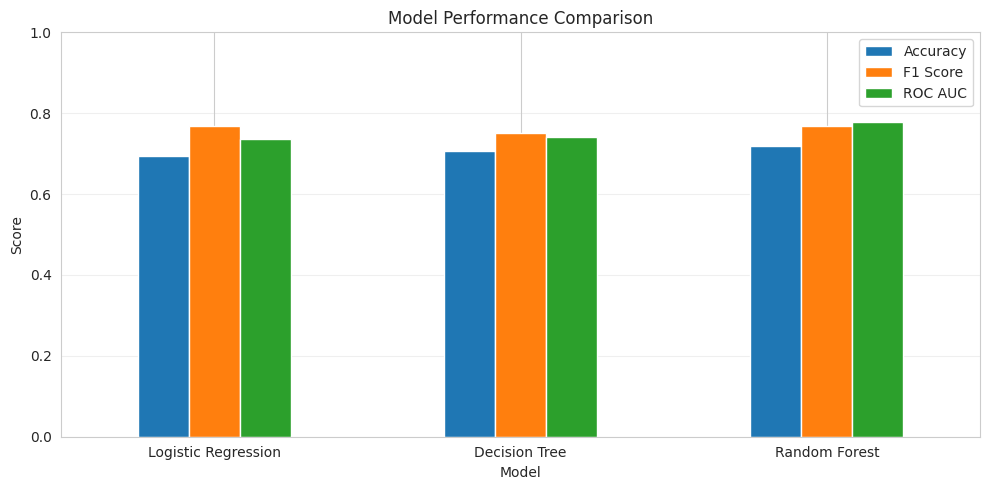

In [25]:
# Model comparison chart
metrics_to_plot = ['Accuracy', 'F1 Score', 'ROC AUC']

comparison_df = results_df.set_index('Model')[metrics_to_plot]

comparison_df.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Random Forest achieved the strongest overall performance across most evaluation metrics, particularly ROC AUC and overall accuracy.

The results indicate that ensemble-based models are more effective at capturing complex startup success patterns compared to linear or single-tree approaches.

## Step 9: Feature Importance Analysis

Feature importance analysis helps identify which startup-related variables contribute most to the Random Forest predictions.

This improves model interpretability and provides business-level insights into startup success patterns.

In [26]:
# Extract feature importance values
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,funding_total_usd,0.228837
4,venture,0.144232
2,founded_year,0.139953
1,funding_rounds,0.074507
9,round_B,0.049639
8,round_A,0.045240
3,seed,0.041717
10,round_C,0.036592
52,country_code_USA,0.031747
5,debt_financing,0.019638


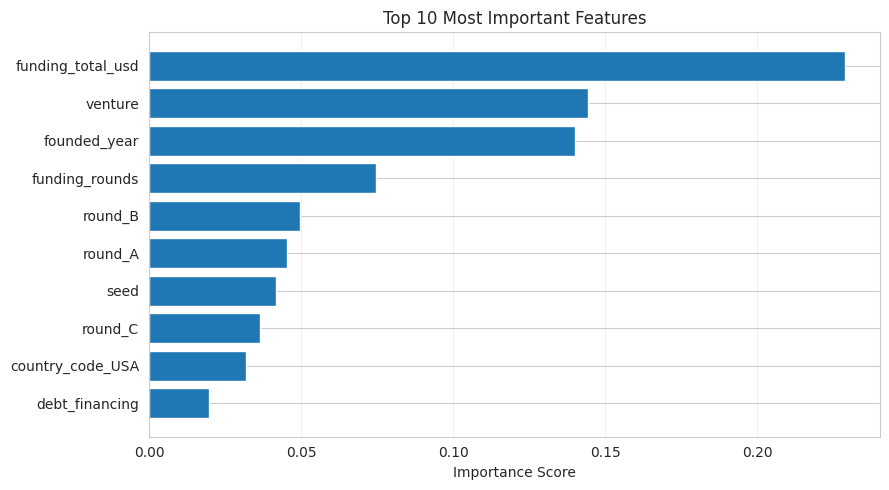

In [27]:
# Plot top feature importances
top_features = feature_importance.head(10)

plt.figure(figsize=(9,5))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel("Importance Score")
plt.title("Top 10 Most Important Features")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Funding-related features such as total funding amount, venture investment, and funding rounds were identified as the strongest predictors of startup success.

The model also revealed that company age (`founded_year`) and geographic location (`country_code_USA`) contribute meaningful predictive information.

Overall, the results suggest that both financial strength and startup maturity play a significant role in acquisition outcomes.

## Step 10: Export Final Model

The final Random Forest model is exported for later use in the StartupCoach application and API inference pipeline.

In [28]:
# Save trained Random Forest model
joblib.dump(rf_model, 'startup_success_model.pkl')

print("✅ Model exported successfully")

✅ Model exported successfully


In [29]:
# Save feature column order
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')

print("✅ Model exported successfully")

✅ Model exported successfully
